In [ ]:
#neural network clasification with pytorch
#Always the first step - Data
import sklearn
from sklearn.datasets import make_circles
n_samples=1000
X,y=make_circles(n_samples,
                  noise=0.03,
                 random_state=42)
len(X),len(y)


(1000, 1000)

In [ ]:
print(X[:5])

[[ 0.75424625  0.23148074]
 [-0.75615888  0.15325888]
 [-0.81539193  0.17328203]
 [-0.39373073  0.69288277]
 [ 0.44220765 -0.89672343]]


In [ ]:
print(y[:5])

[1 1 1 1 0]


In [ ]:
#make datafram of circle data
import pandas as pd
circles=pd.DataFrame({"X1":X[:,0],
                      "X2":X[:,1],
                      "label":y})
circles.head(10)

,X1,X2,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0
5,-0.479646,0.676435,1
6,-0.013648,0.803349,1
7,0.771513,0.147760,1
8,-0.169322,-0.793456,1
9,-0.121486,1.021509,0


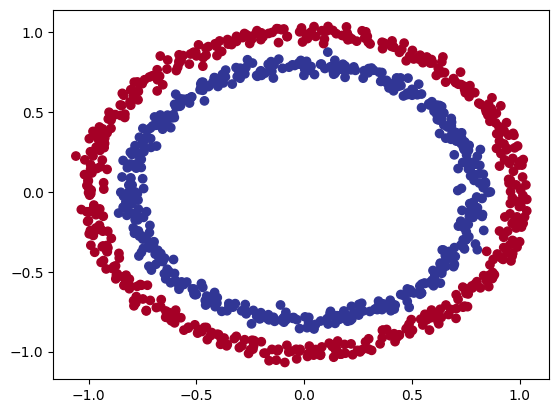

In [ ]:
#visualizing the data
import matplotlib.pyplot as plt
plt.scatter(x=X[:,0],
            y=X[:,1],
            c=y,
            cmap=plt.cm.RdYlBu);


In [ ]:
#check input and output shapes then convert it to torch
X.shape,y.shape

((1000, 2), (1000,))

In [ ]:
x_sample=X[0]
y_sample=y[0]
print(f"{x_sample} and {y_sample}")
print(f"{x_sample.shape} and {y_sample.shape}")



[0.75424625 0.23148074] and 1
(2,) and ()


In [ ]:
#Turn data into tensor and create a train-test split
import torch
X=torch.from_numpy(X).type(torch.float)
y=torch.from_numpy(y).type(torch.float)
X[:5],y[:5]


(tensor([[ 0.7542,  0.2315],
         [-0.7562,  0.1533],
         [-0.8154,  0.1733],
         [-0.3937,  0.6929],
         [ 0.4422, -0.8967]]),
 tensor([1., 1., 1., 1., 0.]))

In [ ]:
torch.manual_seed(42)

In [ ]:
#train and test split
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(
                                              X,
                                              y,
                                              test_size=0.2,
                                              random_state=42
)

In [ ]:
 #setting up the device agnostic code
device="cuda" if torch.cuda.is_available() else "cpu"

In [ ]:
#Build a model- construct a model
import torch
from torch import nn

class Circlemodel(nn.Module):
  def __init__(self):
    super().__init__()
    #self.layer_1=nn.Linear(in_features=2,out_features=5)
    #self.layer_2=nn.Linear(in_features=5,out_features=1)

    self.two_linear_layers=nn.Sequential(
      nn.Linear(in_features=2,out_features=5),
      nn.Linear(in_features=5,out_features=1)

)
  def forward(self,x):
    #return self.layer_2(self.layer_1(x)) #x->layer_1->layer_2->output
    return self.two_linear_layers(x)
  #instantiate an instance of our model class and send it to the target device
model_0=Circlemodel().to(device)
model_0

Circlemodel(
  (two_linear_layers): Sequential(
    (0): Linear(in_features=2, out_features=5, bias=True)
    (1): Linear(in_features=5, out_features=1, bias=True)
  )
)

In [ ]:
model_0.state_dict()

OrderedDict([('two_linear_layers.0.weight',
              tensor([[ 0.5406,  0.5869],
                      [-0.1657,  0.6496],
                      [-0.1549,  0.1427],
                      [-0.3443,  0.4153],
                      [ 0.6233, -0.5188]], device='cuda:0')),
             ('two_linear_layers.0.bias',
              tensor([0.6146, 0.1323, 0.5224, 0.0958, 0.3410], device='cuda:0')),
             ('two_linear_layers.1.weight',
              tensor([[-0.0631,  0.3448,  0.0661, -0.2088,  0.1140]], device='cuda:0')),
             ('two_linear_layers.1.bias', tensor([-0.2060], device='cuda:0'))])

In [ ]:
#make pridictions with the random numbers
with torch.inference_mode():
  untrained_preds=model_0(X_test.to(device))
print(f'length of predictions: {len(untrained_preds)},shape:{untrained_preds.shape}')
print(f'length of test samples: {len(X_test)},shape: {X_test.shape}')
print(f'\nFirst 10 predictions: \n{untrained_preds[:10]}')
print(f'\nFirst 10 labels \n{y_test[:10]}')


length of predictions: 200,shape:torch.Size([200, 1])
length of test samples: 200,shape: torch.Size([200, 2])

First 10 predictions: 
tensor([[-0.1269],
        [-0.0967],
        [-0.1908],
        [-0.1089],
        [-0.1667],
        [-0.1484],
        [-0.0826],
        [-0.0946],
        [-0.1918],
        [-0.0944]], device='cuda:0')

First 10 labels 
tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.])


In [ ]:
#setting up the loss function and optimizer
#loss_fn=nn.BCELoss()#requires pre activation processing
loss_fn=nn.BCEWithLogitsLoss() #have sigmoid activation inside

optimizer=torch.optim.SGD(params=model_0.parameters(),
                         lr=0.1)



In [ ]:
#calculate accuracy
def accuracy_fn(y_true,y_pred):
  correct=torch.eq(y_true,y_pred).sum().item()
  acc=(correct/len(y_pred))*100
  return acc

In [ ]:
#view the ifrst 5 outputs of the forward pass on the test data
model_0.eval()
with torch.inference_mode():
  y_logits=model_0(X_test.to(device))[:5]
y_logits

tensor([[-0.1269],
        [-0.0967],
        [-0.1908],
        [-0.1089],
        [-0.1667]], device='cuda:0')

In [ ]:
#use sigmoid activation function  on the logits
y_pred_probs=torch.sigmoid(y_logits)
torch.round(y_pred_probs)

tensor([[0.],
        [0.],
        [0.],
        [0.],
        [0.]], device='cuda:0')

In [ ]:
#find the predicted labels
y_preds=torch.round(y_pred_probs)

#logits->pred probs ->pred labels
y_pred_labels=torch.round(torch.sigmoid(model_0(X_test.to(device)[:5])))
print(torch.eq(y_preds.squeeze(),y_pred_labels.squeeze()))

y_preds.squeeze()

tensor([True, True, True, True, True], device='cuda:0')


tensor([0., 0., 0., 0., 0.], device='cuda:0')

In [ ]:
  #training the model with a training  and testing loop
torch.manual_seed(42)
torch.cuda.manual_seed(42)


epochs=100
X_train, y_train=X_train.to(device),y_train.to(device)
X_test, y_test=X_test.to(device),y_test.to(device)

for epoch in range(epochs):
    model_0.train()
    #forward pass
    y_logits=model_0(X_train).squeeze()
    y_pred =torch.round(torch.sigmoid(y_logits))

    #calculate loss/accuracy
    loss=loss_fn(y_logits,
                y_train)
    acc=accuracy_fn(y_true=y_train,
                    y_pred=y_pred)
    #optimizer zero grad
    optimizer.zero_grad()
    #loss backward
    loss.backward()
    #optimzer step
    optimizer.step()
    #testing
    model_0.eval()
    with torch.inference_mode():
      test_logits=model_0(X_test).squeeze()
      test_pred=torch.round(torch.sigmoid(test_logits))

      #claculate test loss
      test_loss=loss_fn(test_logits,
                        y_test)
      test_acc=accuracy_fn(y_true=y_test,
                            y_pred=test_pred)

    if epoch %10==0:
      print(f'Epoch :{epoch} | Loss: {loss:.5f}, Acc: {acc:.2f}% |Test loss: {test_loss:.5f},Test acc:{test_acc}')


Epoch :0 | Loss: 0.69569, Acc: 50.00% |Test loss: 0.69721,Test acc:50.0
Epoch :10 | Loss: 0.69403, Acc: 50.00% |Test loss: 0.69615,Test acc:50.0
Epoch :20 | Loss: 0.69343, Acc: 46.00% |Test loss: 0.69585,Test acc:48.5
Epoch :30 | Loss: 0.69321, Acc: 49.00% |Test loss: 0.69577,Test acc:47.5
Epoch :40 | Loss: 0.69312, Acc: 49.50% |Test loss: 0.69573,Test acc:46.5
Epoch :50 | Loss: 0.69308, Acc: 50.38% |Test loss: 0.69569,Test acc:46.5
Epoch :60 | Loss: 0.69306, Acc: 50.50% |Test loss: 0.69564,Test acc:46.5
Epoch :70 | Loss: 0.69305, Acc: 50.50% |Test loss: 0.69559,Test acc:46.5
Epoch :80 | Loss: 0.69304, Acc: 50.75% |Test loss: 0.69553,Test acc:46.5
Epoch :90 | Loss: 0.69303, Acc: 50.38% |Test loss: 0.69547,Test acc:46.5


In [ ]:
#we can see theat the model is doing very badly and it is the same as gueesing randlomly
  #let's try to make prediction and
import requests
from pathlib import Path
#download helper functions from repo
if Path('helper_function.py').is_file():
  print('helper function already exist')
else:
  request=requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
  with open("helper_function.py","wb") as f:
    f.write(request.content)

from helper_function import plot_predictions,plot_decision_boundary



helper function already exist


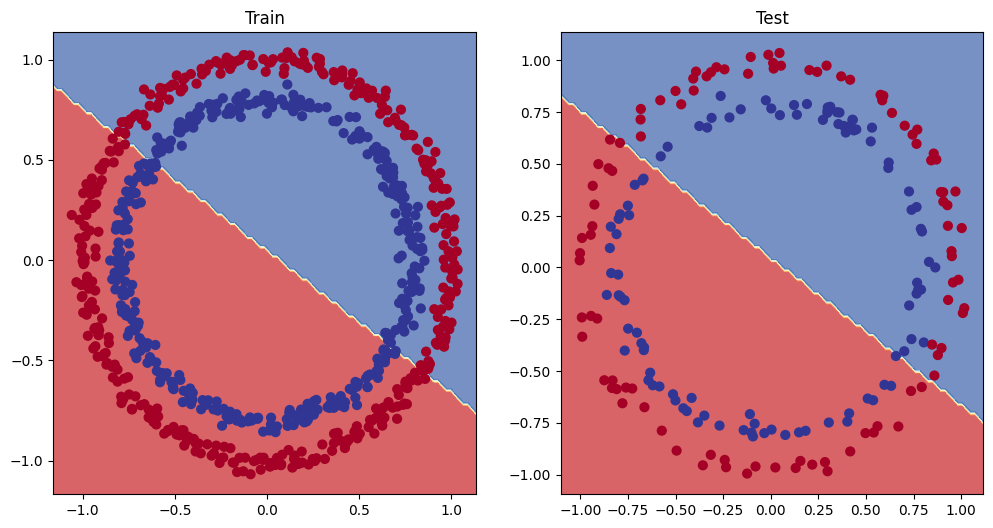

In [ ]:
#plot decsion boundary of the model
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model_0,X_train,y_train)
plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(model_0,X_test,y_test)


In [ ]:
#try to improve our model
class CircleModelV1(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer_1=nn.Linear(in_features=2,out_features=10)
    self.layer_2=nn.Linear(in_features=10,out_features=10)
    self.layer_3=nn.Linear(in_features=10,out_features=1)

  def forward(self,x):
    # z=self.layer_1(x)
    # z=self.layer_2(z)
    # z=self.layer_3(z)
    return self.layer_3(self.layer_2(self.layer_1(x)))
model_1=CircleModelV1().to(device)
model_1



CircleModelV1(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
)

In [ ]:
#create a loss function and optimizer
loss_fn=nn.BCEWithLogitsLoss() #have sigmoid activation inside

optimizer=torch.optim.SGD(params=model_0.parameters(),
                         lr=0.1)

  #training the model with a training  and testing loop
torch.manual_seed(42)
torch.cuda.manual_seed(42)


epochs=1000
X_train, y_train=X_train.to(device),y_train.to(device)
X_test, y_test=X_test.to(device),y_test.to(device)

for epoch in range(epochs):
    model_1.train()
    #forward pass
    y_logits=model_1(X_train).squeeze()
    y_pred =torch.round(torch.sigmoid(y_logits))

    #calculate loss/accuracy
    loss=loss_fn(y_logits,
                y_train)
    acc=accuracy_fn(y_true=y_train,
                    y_pred=y_pred)
    #optimizer zero grad
    optimizer.zero_grad()
    #loss backward
    loss.backward()
    #optimzer step
    optimizer.step()
    #testing
    model_1.eval()
    with torch.inference_mode():
      test_logits=model_1(X_test).squeeze()
      test_pred=torch.round(torch.sigmoid(test_logits))

      #claculate test loss
      test_loss=loss_fn(test_logits,
                        y_test)
      test_acc=accuracy_fn(y_true=y_test,
                            y_pred=test_pred)

    if epoch %100==0:
      print(f'Epoch :{epoch} | Loss: {loss:.5f}, Acc: {acc:.2f}% |Test loss: {test_loss:.5f},Test acc:{test_acc}')


Epoch :0 | Loss: 0.69396, Acc: 50.88% |Test loss: 0.69261,Test acc:51.0
Epoch :100 | Loss: 0.69396, Acc: 50.88% |Test loss: 0.69261,Test acc:51.0
Epoch :200 | Loss: 0.69396, Acc: 50.88% |Test loss: 0.69261,Test acc:51.0
Epoch :300 | Loss: 0.69396, Acc: 50.88% |Test loss: 0.69261,Test acc:51.0
Epoch :400 | Loss: 0.69396, Acc: 50.88% |Test loss: 0.69261,Test acc:51.0
Epoch :500 | Loss: 0.69396, Acc: 50.88% |Test loss: 0.69261,Test acc:51.0
Epoch :600 | Loss: 0.69396, Acc: 50.88% |Test loss: 0.69261,Test acc:51.0
Epoch :700 | Loss: 0.69396, Acc: 50.88% |Test loss: 0.69261,Test acc:51.0
Epoch :800 | Loss: 0.69396, Acc: 50.88% |Test loss: 0.69261,Test acc:51.0
Epoch :900 | Loss: 0.69396, Acc: 50.88% |Test loss: 0.69261,Test acc:51.0


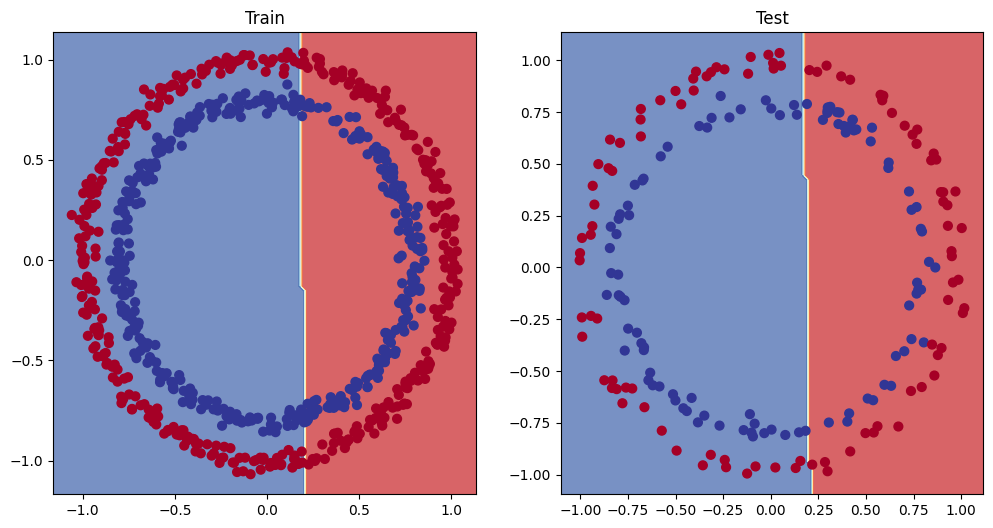

In [ ]:
#plot decision boundary
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model_1,X_train,y_train)
plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(model_1,X_test,y_test)


Still no improvment??non linear activation?

In [ ]:
 #non linearity
 #convert data to tensors to train and split
import torch
from sklearn.model_selection import train_test_split


 #split into train and test sets
X_train,x_test,y_train,y_test=train_test_split(X,
                                                y,
                                                test_size=0.2,
                                                random_state=42)
X_train[:5],y_train[:5]


(tensor([[ 0.6579, -0.4651],
         [ 0.6319, -0.7347],
         [-1.0086, -0.1240],
         [-0.9666, -0.2256],
         [-0.1666,  0.7994]]),
 tensor([1., 0., 0., 0., 1.]))

In [ ]:
## building a model with non-linearity-non linear activation function
from torch import nn
class CircleModelV2(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer_1=nn.Linear(in_features=2,out_features=10)
    self.layer_2=nn.Linear(in_features=10,out_features=10)
    self.layer_3=nn.Linear(in_features=10,out_features=1)
    self.relu=nn.ReLU()

  def forward(self,x):
    return self.layer_3(self.relu(self.layer_2(self.relu(self.layer_1(x)))))

model_2=CircleModelV1().to(device)
model_2


CircleModelV1(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
)

In [ ]:
#set up loss and optimizer
loss_fn=nn.BCEWithLogitsLoss()
optimizer=torch.optim.SGD(model_2.parameters(),
                          lr=0.01)


In [ ]:
#training model
torch.manual_seed(42)
torch.cuda.manual_seed(42)

X_train, y_train=X_train.to(device),y_train.to(device)
X_test, y_test=X_test.to(device),y_test.to(device)

epochs=1000

for epoch in range(epochs):
  model_2.train()

  y_logits=model_2(X_train).squeeze()
  y_pred=torch.round(torch.sigmoid(y_logits))

  loss=loss_fn(y_logits,y_train)
  acc=accuracy_fn(y_true=y_train,
                  y_pred=y_pred)

  optimizer.zero_grad()

  loss.backward()

  optimizer.step()
  #testing
  model_2.eval()
  with torch.inference_mode():
    test_logits=model_2(X_test)
    test_pred=torch.round(torch.sigmoid(test_logits))

    #claculate test loss
    test_loss=loss_fn(test_logits,
                      y_test)
    test_acc=accuracy_fn(y_true=y_test,
                          y_pred=test_pred)

  if epoch %100==0:
    print(f'Epoch :{epoch} | Loss: {loss:.5f}, Acc: {acc:.2f}% |Test loss: {test_loss:.5f},Test acc:{test_acc}')


ValueError: Target size (torch.Size([200])) must be the same as input size (torch.Size([200, 1]))